# Asteroid Sonification
Adrián García Riber 2025, SVO.

This research has made use of the Spanish Virtual Observatory (https://svo.cab.inta-csic.es) project funded by MCIN/AEI/10.13039/501100011033 through grant PID2023-146210NB-I00.

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
from numpy.lib.stride_tricks import sliding_window_view

In [2]:
def load_image (route):
    image = mpimg.imread(route)
    imgplot = plt.imshow(image)
    plt.show()
    return image

In [3]:
def filtering (channel, threshold):
    height_dim = channel.shape[0]
    width_dim = channel.shape[1]
    alpha_dim = channel.shape[2]
    filtered_img= np.ones((height_dim, width_dim, alpha_dim))
    for i in range(height_dim):
        for j in range(width_dim):
            if channel [i][j][0] < threshold:
                filtered_img [i][j][0] = 0.01 #channel [i][j][0] #0.01 #White
    return (filtered_img)

In [4]:
def show_filter (filtered_img):
    plt.imshow(filtered_img [:,:,0], cmap='Blues')
    plt.show()

In [5]:
def save_for_gif (filtered_img, index):
    plt.imshow(filtered_img [:,:,0], cmap='Blues')
    plt.savefig(f'frame_{index}.png')
    plt.show()

## Explore the image and find the threshold

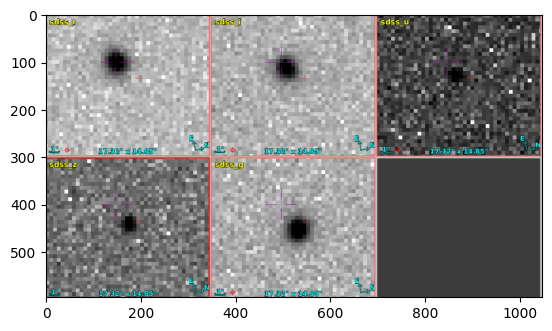

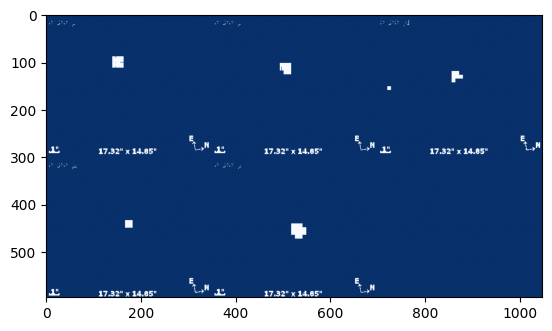

In [6]:
threshold = .01             #Find the best common threshold to filter the asteroid => TO DO: automatic adjustment
file = 'Fenucci_detected_zoom.png'
channel = load_image(file)
filtered = filtering(channel, threshold)
show_filter(filtered)

Extracting the images

In [7]:
def extract_zone(input_png, output_png, x, y, width, height, preview=True):
    with Image.open(input_png) as img:
        img_w, img_h = img.size

        left = max(0, x)
        top = max(0, y)
        right = min(img_w, x + width)
        bottom = min(img_h, y + height)

        if left >= right or top >= bottom:
            raise ValueError("Invalid crop region.")

        cropped = img.crop((left, top, right, bottom))

        if preview:
            cropped.show()
            cropped.save(output_png, "PNG")
            print(f"Saved as {output_png}")
 

In [8]:
folder = os.path.splitext(file)
folder

('Fenucci_detected_zoom', '.png')

In [9]:
folder[0]+ "/g" +folder[1]

'Fenucci_detected_zoom/g.png'

In [10]:
if not os.path.exists(folder[0]):
    os.makedirs(folder[0])
extract_zone(file, folder[0]+ "/g" +folder[1], x=350, y=300, width=350, height=300) # channel "g
extract_zone(file, folder[0]+ "/i" +folder[1], x=350, y=0, width=350, height=300) # channel "i"
extract_zone(file, folder[0]+ "/r" +folder[1], x=0, y=0, width=350, height=300) # channel "r"
extract_zone(file, folder[0]+ "/u" +folder[1], x=700, y=0, width=350, height=300) # channel "u"
extract_zone(file, folder[0]+ "/z" +folder[1], x=0, y=300, width=350, height=300) # channel "z"

Saved as Fenucci_detected_zoom/g.png
Saved as Fenucci_detected_zoom/i.png
Saved as Fenucci_detected_zoom/r.png
Saved as Fenucci_detected_zoom/u.png
Saved as Fenucci_detected_zoom/z.png


## Pre-procesing .png files

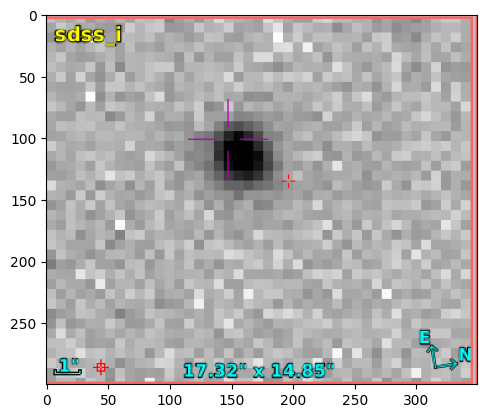

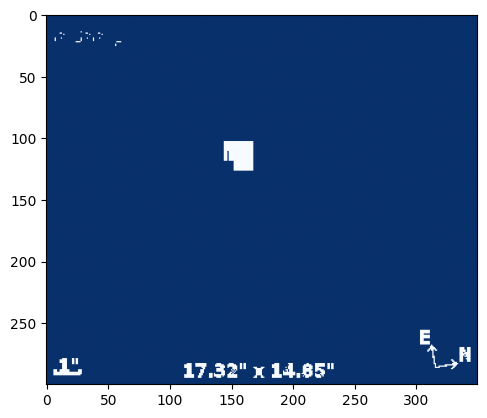

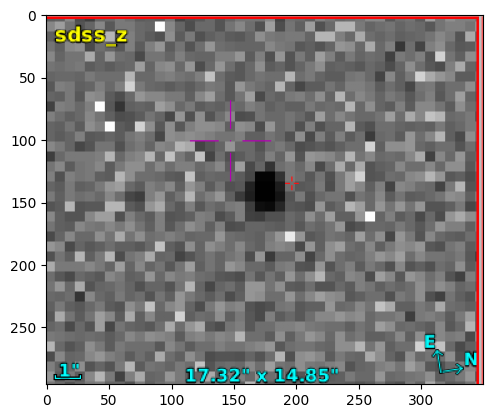

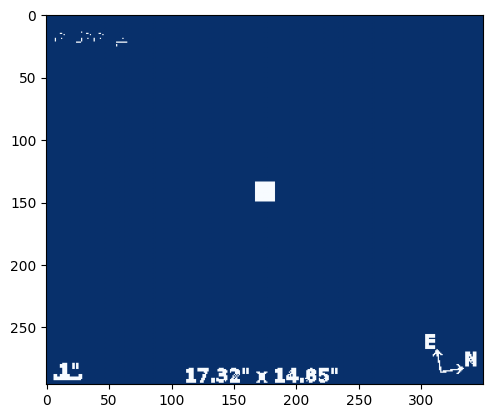

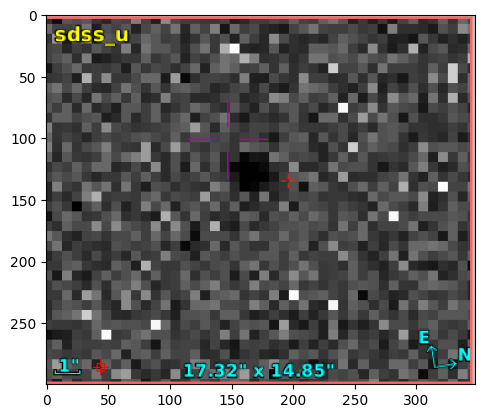

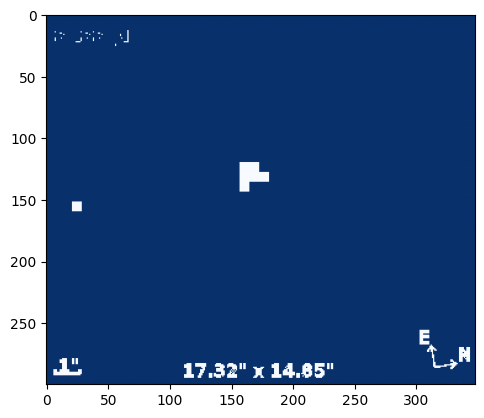

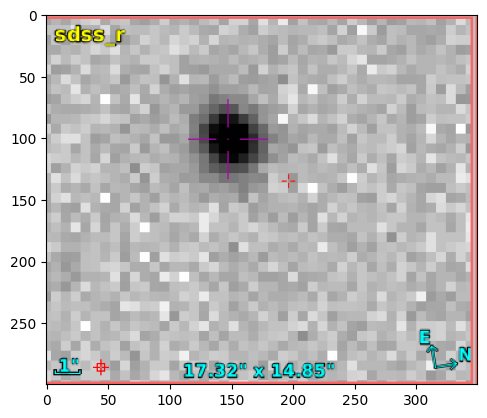

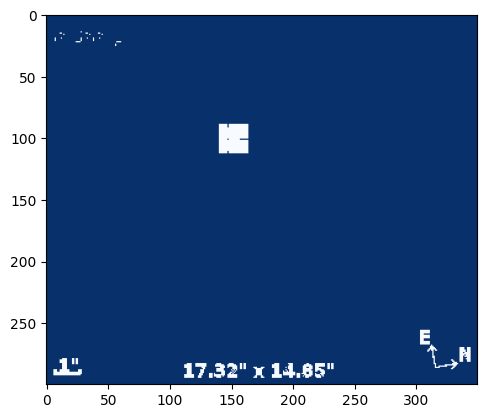

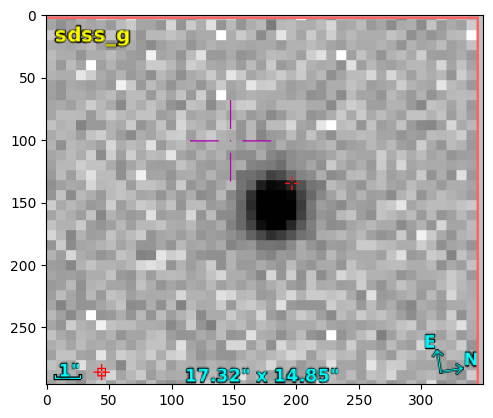

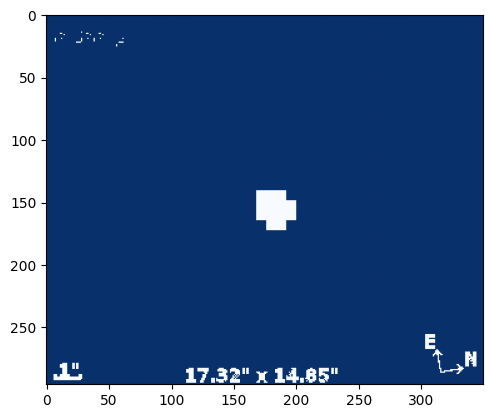

In [11]:
# Different thresholds may be needed in noisy obsservations. => TO DO: Automatic adjustement by channel
for file in os.listdir(folder[0]):
    file_name = os.path.join(folder[0],file)
    channel = load_image(file_name)
    channel_name = file_name.split('/')[1]
    if channel_name.startswith("r"): 
        threshold = 0.01         #r channel: threshold = 0.01
        frame = 0
    if channel_name.startswith("i"): 
        threshold = 0.01         #i channel: threshold = 0.01
        frame = 1
    if channel_name.startswith("u"): 
        threshold = 0.01        #u channel: threshold = 0.01
        frame = 2
    if channel_name.startswith("z"): 
        threshold = 0.01        #z channel: threshold = 0.01  
        frame = 3
    if channel_name.startswith("g"): 
        threshold = 0.01        #g channel: threshold = 0.01
        frame = 4
    filtered = filtering(channel, threshold)
    save_for_gif(filtered,frame)

If ".DS_Store" errors appear: run from terminal in the folder => find . -name ".DS_Store" -delete


## Generating filtered .gif

!pip3 install pillow

In [12]:
folder[0]+"-gif"

'Fenucci_detected_zoom-gif'

In [13]:
images = [Image.open(f"frame_{i}.png") for i in range(4)]
gif_folder = folder[0]+ "-gif"
if not os.path.exists(gif_folder):
    os.makedirs(gif_folder)
images[0].save(
    gif_folder + "/" + folder[0] + "-filtered.gif",
    save_all=True,
    append_images=images[1:],
    duration=500,    # milliseconds per frame
    loop=1           # loop forever
)